# Nested CV: XGBoost interval hazard

Outer loop uses the fixed user folds in `user_folds_personal_14.csv`.
On each outer train set, hyperparameters are chosen by **mean inner 5-fold logloss**
(GroupKFold by `user_id`), then the best params are refit on the full outer train
and scored on the held-out outer test fold.

Covariates match the other models, plus numeric `interval_id` (`interval_start / 14`),
the same duration index M2a/M2b use as a per-interval intercept.

Objective: `binary:logistic` (native logloss).

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import xgboost as xgb
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import GroupKFold, RandomizedSearchCV

PROJECT_ROOT = next(
    candidate
    for parent in (Path.cwd(), *Path.cwd().parents)
    for candidate in (parent, parent / "Coding")
    if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir()
)
os.chdir(PROJECT_ROOT)

from src.constants import paths_to_files_and_folders as const
from src.constants import thesis_plotting_style as style
from src.constants.variables_groupings import COX_BAN_LIST, pretty_new_features

sns.set_theme(**style.SEABORN_THEME)

FIGURE_DIR = PROJECT_ROOT.parent / "Output" / "07_xgboost"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT

/Users/tomas.p/Desktop/Survival_Analysis_Thesis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PosixPath('/Users/tomas.p/Desktop/Survival_Analysis_Thesis/Coding')

In [2]:
final_dir = const.PATH_TO_FINAL_DATA

features = pd.read_csv(
    final_dir / "features_personal_14_day_intervals_new_features.csv"
)
folds = pd.read_csv(final_dir / "user_folds_personal_14.csv")

n_before = len(features)
df = features.merge(folds, on="user_id", how="left", validate="many_to_one")
assert len(df) == n_before and df["fold"].notna().all()

# Same duration index M2a/M2b use as a free intercept (interval_start / 14).
# Trees get it as a numeric split; start/end stay out of X so we do not
# double-encode the clock.
df["interval_id"] = df["interval_start"] / 14

ID_COLS = ["user_id", "fold", "interval_start", "interval_end", "churn_triggered_adjusted"]
feature_cols = [
    c
    for c in df.columns
    if c not in ID_COLS and c not in COX_BAN_LIST
]

y_col = "churn_triggered_adjusted"
outer_folds = sorted(df["fold"].unique())
print(f"rows={len(df):,} users={df['user_id'].nunique():,} features={len(feature_cols)}")
print("features:", feature_cols)

rows=124,783 users=6,000 features=28
features: ['prop_clear_0_56', 'prop_coding_0_56', 'prop_history_screen_0_56', 'prop_live_data_0_56', 'prop_oca_0_56', 'prop_scan_0_56', 'prop_main_0_56', 'prop_main_drift_0_28_vs_28_56', 'n_sessions_0_28_days', 'sessions_intensity_drift_0_28_vs_28_56_days', 'actions_per_session_0_28_days', 'actions_per_session_intensity_drift_0_28_vs_28_56_days', 'weekend_share_0_28_days', 'usage_concentration', 'vehicle_mean_age_overall', 'vehicle_age_sd_overall', 'prop_in_prod', 'vehicle_mean_mileage_ordinal', 'n_new_vehicles_0_28_days', 'days_since_last_new_vehicle', 'overall_prop_vehicle_make_audi', 'overall_prop_vehicle_make_skoda', 'overall_prop_vehicle_make_volkswagen', 'active_flag_0_56_days', 'mean_gap_0_56_days', 'sd_gap_0_56_days', 'onboarding_delay_days', 'interval_id']


In [3]:
RANDOM_STATE = 42
INNER_SPLITS = 5
N_ITER = 25  # randomized search budget per outer fold

base_estimator = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

param_distributions = {
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.03, 0.05, 0.1],
    "n_estimators": [100, 200, 400],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda": [1.0, 5.0, 10.0],
}

In [4]:
oof_frames = []
best_params_rows = []
shap_value_frames = []  # per-fold SHAP values, aligned row-for-row with oof_frames
shap_input_frames = []  # matching X_test rows, needed for the summary/beeswarm plot

for k in outer_folds:
    train = df[df["fold"] != k]
    test = df[df["fold"] == k]

    X_train = train[feature_cols]
    y_train = train[y_col].astype(int)
    groups_train = train["user_id"]

    X_test = test[feature_cols]
    y_test = test[y_col].astype(int)

    inner_cv = GroupKFold(n_splits=INNER_SPLITS)
    search = RandomizedSearchCV(
        estimator=base_estimator,
        param_distributions=param_distributions,
        n_iter=N_ITER,
        scoring="neg_log_loss",
        cv=inner_cv,
        refit=True,
        n_jobs=-1,
        random_state=RANDOM_STATE + int(k),
        verbose=1,
    )
    search.fit(X_train, y_train, groups=groups_train)

    h = search.predict_proba(X_test)[:, 1]
    mean_inner_logloss = -search.best_score_

    # SHAP values from the fold's own refit model, evaluated only on the
    # held-out test rows it never trained on -- the same out-of-fold logic
    # already used for h above, so aggregate driver rankings stay leak-free.
    explainer = shap.TreeExplainer(search.best_estimator_)
    shap_value_frames.append(explainer.shap_values(X_test))
    shap_input_frames.append(X_test)

    print(
        f"outer fold {k}: best mean inner logloss={mean_inner_logloss:.5f} "
        f"params={search.best_params_}"
    )

    best_params_rows.append(
        {"fold": k, "mean_inner_logloss": mean_inner_logloss, **search.best_params_}
    )
    oof_frames.append(
        pd.DataFrame(
            {
                "model": "XGB",
                "fold": k,
                "user_id": test["user_id"].to_numpy(),
                "d": y_test.to_numpy(),
                "h": h,
            }
        )
    )

oof = pd.concat(oof_frames, ignore_index=True)
best_params = pd.DataFrame(best_params_rows).sort_values("fold")

# Row order matches oof exactly: both are built by appending once per fold,
# in the same fold loop, before anything is concatenated.
shap_values_oof = np.vstack(shap_value_frames)
X_oof = pd.concat(shap_input_frames, ignore_index=True)
assert shap_values_oof.shape == (len(oof), len(feature_cols))

oof_path = final_dir / "oof_predictions_xgboost.csv"
params_path = final_dir / "xgboost_best_params_per_fold.csv"
shap_path = final_dir / "xgboost_shap_values_oof.npy"
oof.to_csv(oof_path, index=False)
best_params.to_csv(params_path, index=False)
np.save(shap_path, shap_values_oof)

print(f"wrote {oof_path} ({len(oof):,} rows)")
print(f"wrote {params_path}")
print(f"wrote {shap_path} (shape {shap_values_oof.shape})")
best_params

Fitting 5 folds for each of 25 candidates, totalling 125 fits


outer fold 0: best mean inner logloss=0.10170 params={'subsample': 1.0, 'reg_lambda': 5.0, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Fitting 5 folds for each of 25 candidates, totalling 125 fits


/Users/tomas.p/Desktop/Survival_Analysis_Thesis/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


outer fold 1: best mean inner logloss=0.10167 params={'subsample': 0.6, 'reg_lambda': 10.0, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.6}
Fitting 5 folds for each of 25 candidates, totalling 125 fits


outer fold 2: best mean inner logloss=0.10179 params={'subsample': 0.6, 'reg_lambda': 10.0, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
Fitting 5 folds for each of 25 candidates, totalling 125 fits


outer fold 3: best mean inner logloss=0.10167 params={'subsample': 0.8, 'reg_lambda': 5.0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
Fitting 5 folds for each of 25 candidates, totalling 125 fits


outer fold 4: best mean inner logloss=0.10191 params={'subsample': 0.6, 'reg_lambda': 1.0, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


wrote /Users/tomas.p/Desktop/Survival_Analysis_Thesis/Coding/Data/final/oof_predictions_xgboost.csv (124,783 rows)
wrote /Users/tomas.p/Desktop/Survival_Analysis_Thesis/Coding/Data/final/xgboost_best_params_per_fold.csv
wrote /Users/tomas.p/Desktop/Survival_Analysis_Thesis/Coding/Data/final/xgboost_shap_values_oof.npy (shape (124783, 28))


,fold,mean_inner_logloss,subsample,reg_lambda,n_estimators,min_child_weight,max_depth,learning_rate,colsample_bytree
0,0,0.101701,1.0,5.0,200,5,3,0.05,1.0
1,1,0.101665,0.6,10.0,400,1,4,0.03,0.6
2,2,0.101790,0.6,10.0,200,5,3,0.05,0.6
3,3,0.101668,0.8,5.0,200,3,4,0.05,0.6
4,4,0.101912,0.6,1.0,100,1,3,0.05,1.0


In [5]:
# Quick sanity: calibration of OOF hazards vs observed event rate
summary = (
    oof.groupby("fold", as_index=False)
    .agg(
        n=("d", "size"),
        events=("d", "sum"),
        obs_rate=("d", "mean"),
        mean_h=("h", "mean"),
    )
    .assign(calib=lambda x: x["mean_h"] / x["obs_rate"])
)
summary

,fold,n,events,obs_rate,mean_h,calib
0,0,25094,554,0.022077,0.022879,1.036338
1,1,24772,555,0.022404,0.021730,0.969922
2,2,25071,555,0.022137,0.022255,1.005324
3,3,24722,555,0.022450,0.022340,0.995114
4,4,25124,555,0.022090,0.022591,1.022673


## SHAP: main drivers of the XGBoost model

Global importance (mean |SHAP|, out-of-fold) ranks every feature by its average
contribution to the predicted churn hazard, and the beeswarm below shows the
direction of each feature's effect (colour = the feature's own value, position
= its pull on the prediction), computed identically to `oof_predictions_xgboost.csv`:
each row's SHAP values come only from the fold model that never saw it in
training.

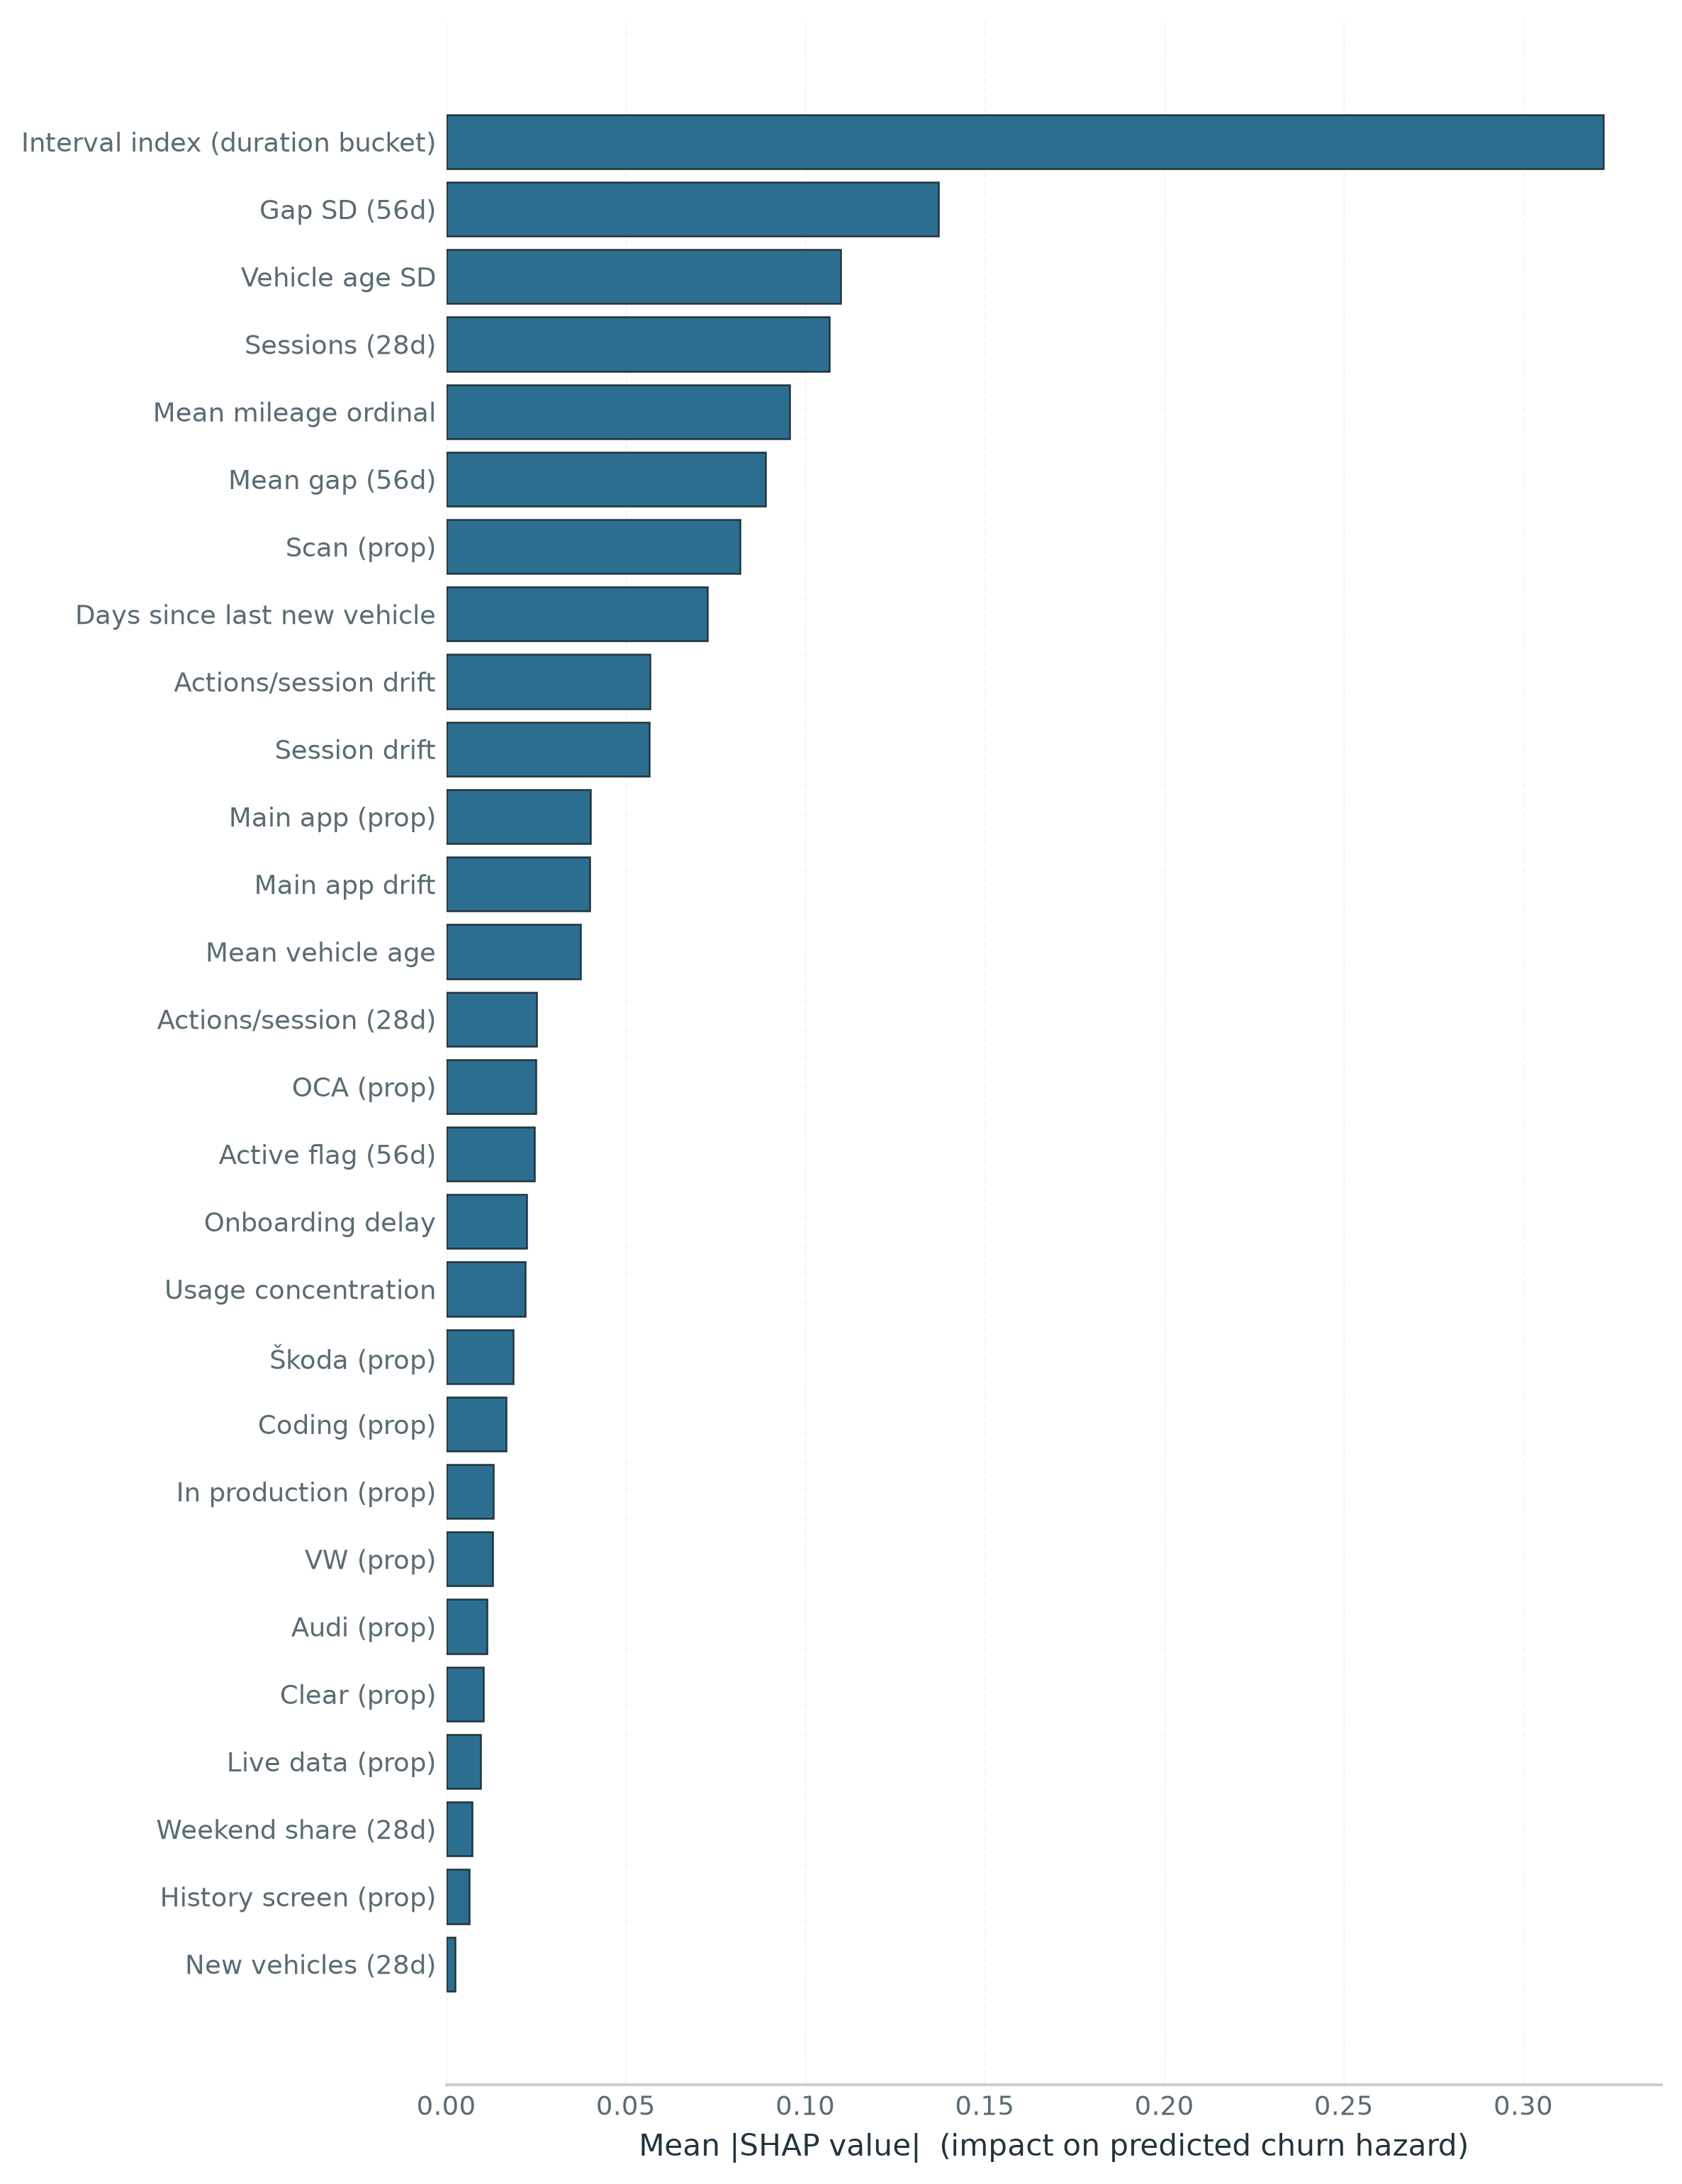

wrote /Users/tomas.p/Desktop/Survival_Analysis_Thesis/Coding/Data/final/xgboost_shap_importance.csv


Interval index (duration bucket)    0.322282
Gap SD (56d)                        0.137187
Vehicle age SD                      0.109864
Sessions (28d)                      0.106768
Mean mileage ordinal                0.095690
Mean gap (56d)                      0.088827
Scan (prop)                         0.081776
Days since last new vehicle         0.072690
Actions/session drift               0.056740
Session drift                       0.056504
dtype: float32

In [6]:
importance = (
    pd.Series(np.abs(shap_values_oof).mean(axis=0), index=feature_cols)
    .rename(index=lambda c: pretty_new_features.get(c, c))
    .sort_values(ascending=True)
)

importance_path = final_dir / "xgboost_shap_importance.csv"
(
    importance.rename_axis("feature")
    .reset_index(name="mean_abs_shap")
    .sort_values("mean_abs_shap", ascending=False)
    .to_csv(importance_path, index=False)
)

fig, ax = plt.subplots(figsize=(8, 0.32 * len(importance) + 1.4))
ax.barh(
    importance.index,
    importance.to_numpy(),
    color=style.PALETTE["Professional"],
    edgecolor=style.COLORS["text"],
    linewidth=0.6,
)
ax.set_xlabel("Mean |SHAP value|  (impact on predicted churn hazard)")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.45)
ax.set_axisbelow(True)
ax.tick_params(length=0)
sns.despine(ax=ax, left=True)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "01_shap_importance.png",
    bbox_inches="tight", facecolor=style.COLORS["background"],
)
plt.show()

print(f"wrote {importance_path}")
importance.sort_values(ascending=False).head(10)

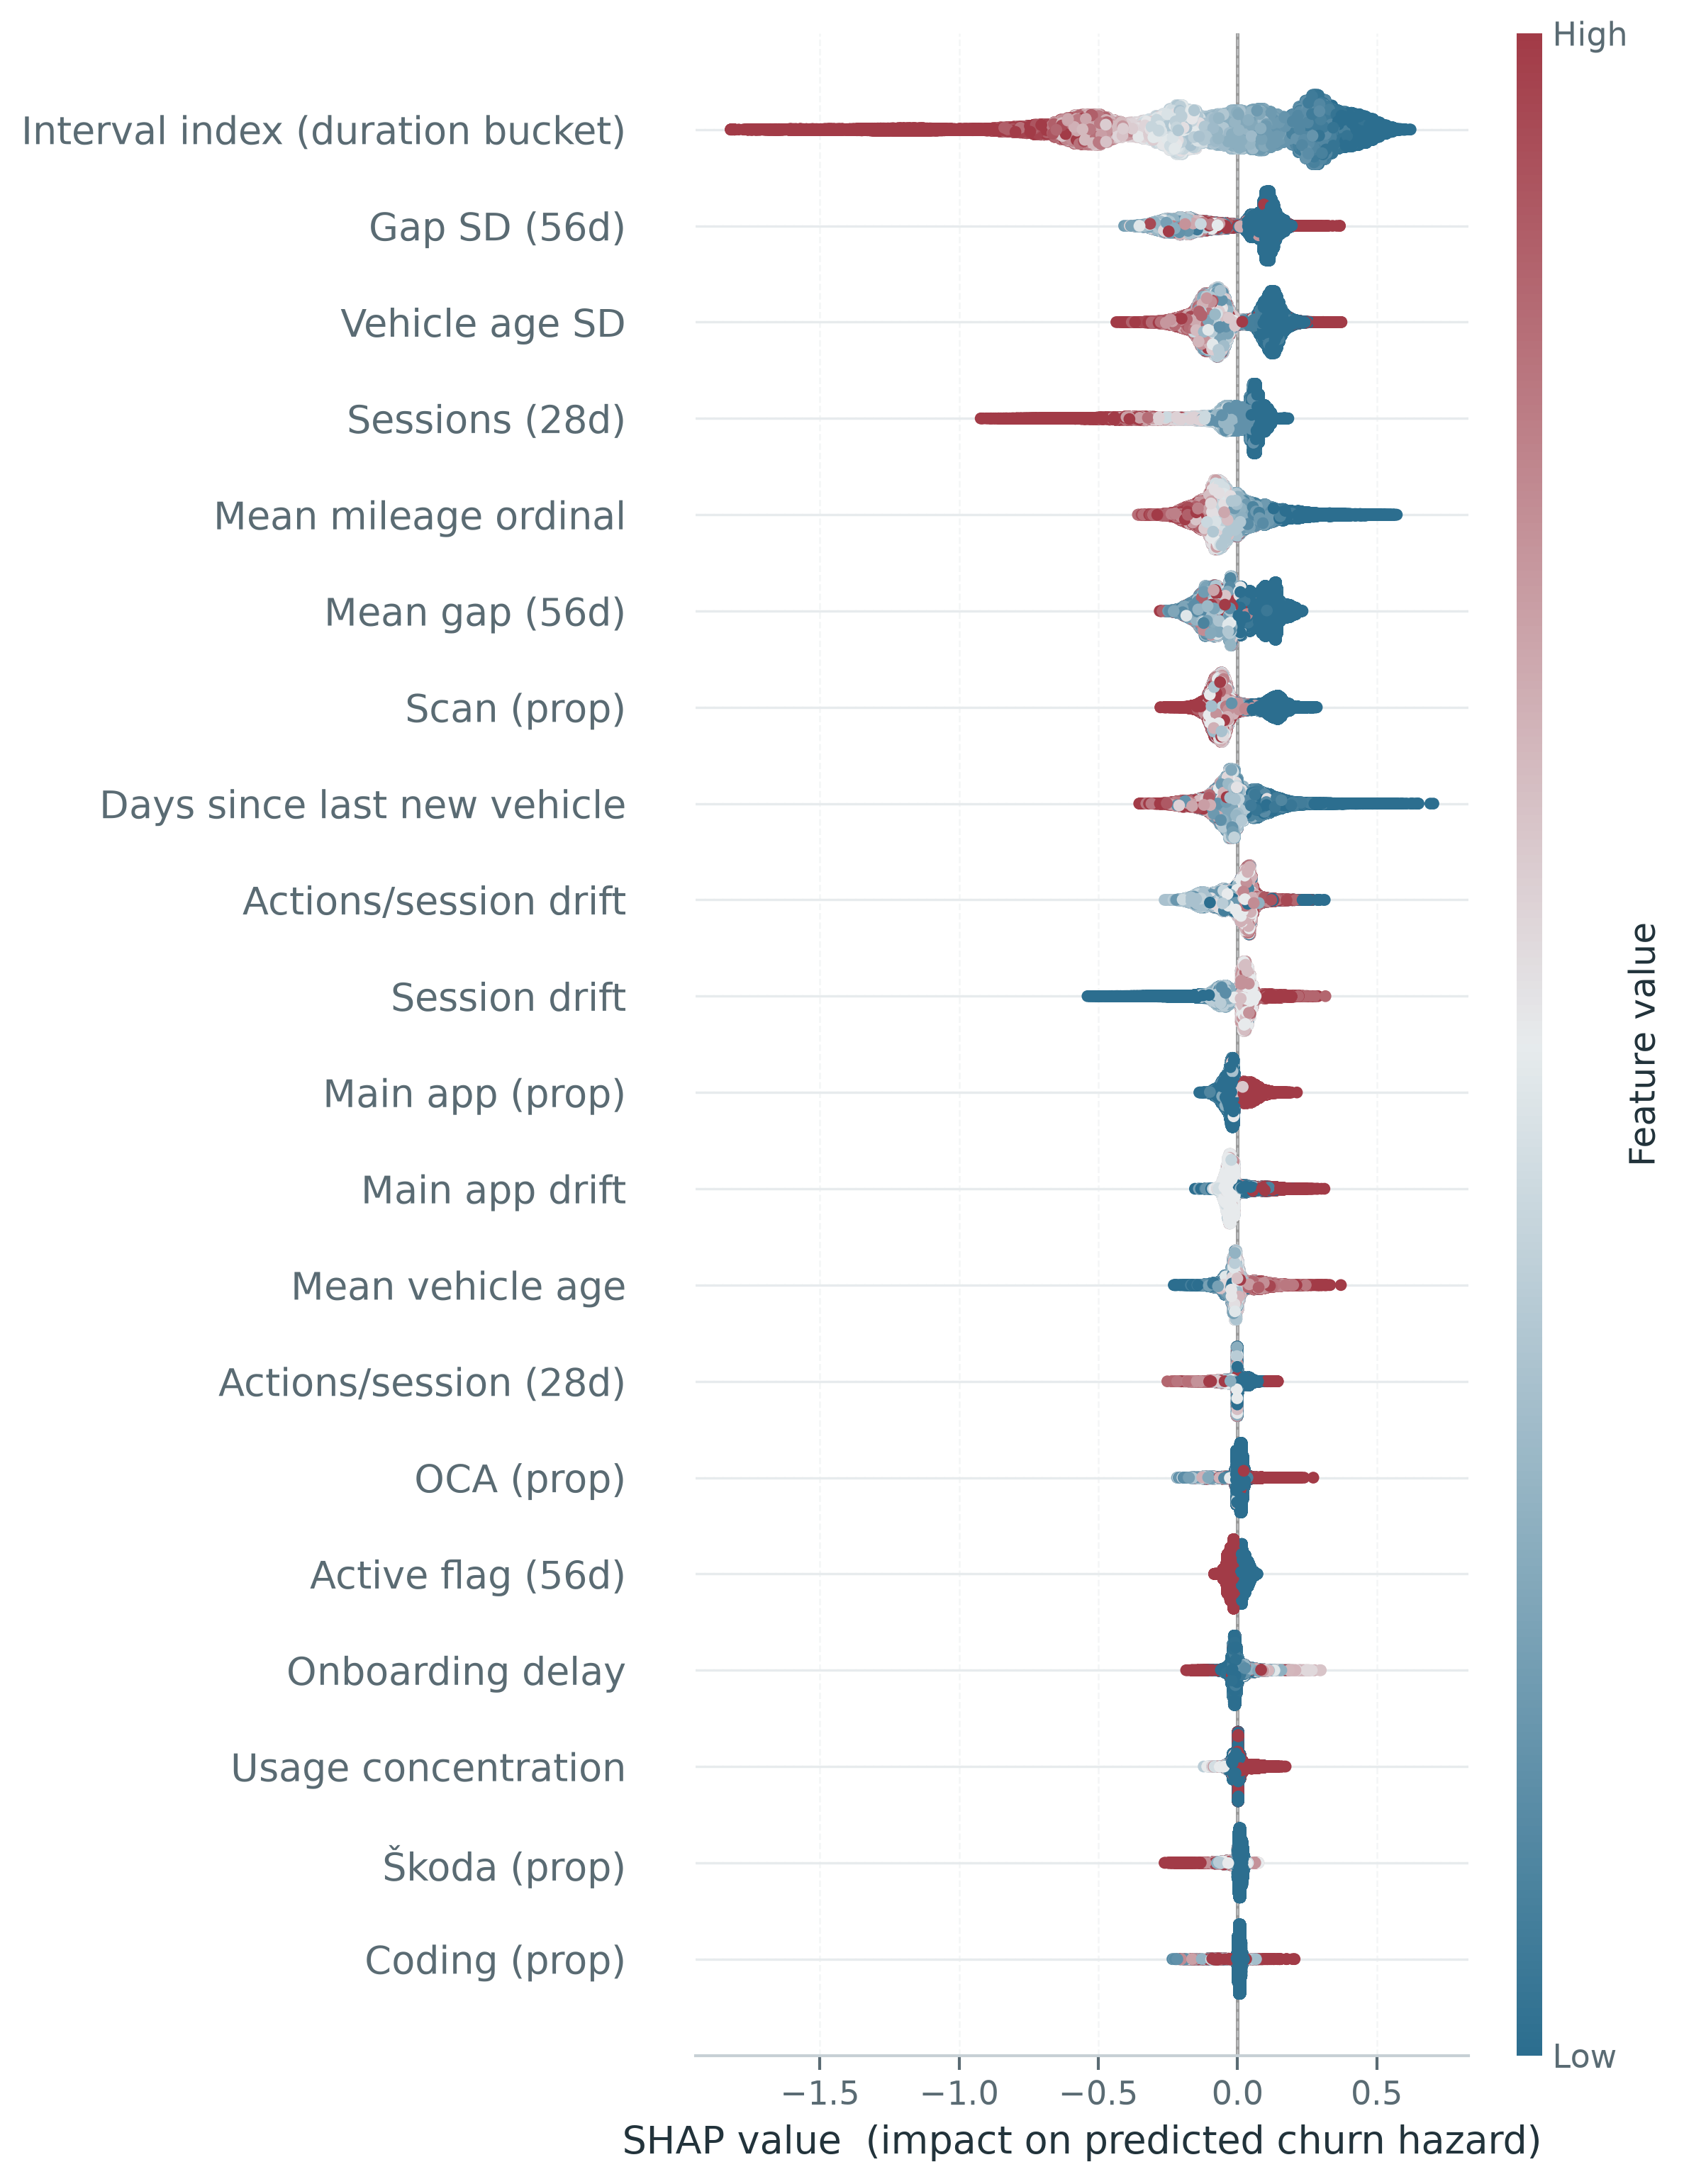

In [7]:
feature_labels = [pretty_new_features.get(c, c) for c in feature_cols]

# Recolour shap's default blue/violet/red diverging map onto the thesis
# palette (low = Professional blue, high = highlight brick red) so the
# beeswarm reads as part of the same document as the other figures.
thesis_diverging_cmap = LinearSegmentedColormap.from_list(
    "thesis_diverging",
    [style.PALETTE["Professional"], style.COLORS["grid"], style.COLORS["highlight"]],
)

shap.summary_plot(
    shap_values_oof,
    X_oof,
    feature_names=feature_labels,
    show=False,
    plot_size=(8, 0.32 * len(feature_cols) + 1.4),
    cmap=thesis_diverging_cmap,
    axis_color=style.COLORS["secondary_text"],
)
fig = plt.gcf()
ax = plt.gca()
fig.patch.set_facecolor(style.COLORS["background"])
ax.set_facecolor(style.COLORS["background"])
ax.set_xlabel("SHAP value  (impact on predicted churn hazard)", color=style.COLORS["text"])
ax.tick_params(colors=style.COLORS["secondary_text"])
ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.45, color=style.COLORS["grid"])
ax.set_axisbelow(True)
sns.despine(ax=ax, left=True)

# shap draws its own colourbar as a second axes on the figure; restyle it
# to match (thesis ink for the "Low"/"High" labels, no hard border).
cax = fig.axes[-1]
cax.tick_params(colors=style.COLORS["secondary_text"], length=0)
cax.set_ylabel(cax.get_ylabel(), color=style.COLORS["text"])
for spine in cax.spines.values():
    spine.set_visible(False)

fig.savefig(
    FIGURE_DIR / "02_shap_summary.png",
    bbox_inches="tight", facecolor=style.COLORS["background"],
)
plt.show()